
# SaaS Metrics Intelligence Dashboard — EDA & Validation (Enhanced)

## Business Context
A Series B SaaS company requires a unified view of revenue health, churn dynamics, cohort retention, and unit economics before KPI modeling and board reporting.

This notebook validates synthetic SaaS data and produces recruiter‑ready insights and chart assets for SQL + Power BI development.


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

plt.rcParams['figure.figsize'] = (10,5)
pd.set_option('display.max_columns', None)

OUT = Path('../output/eda_charts')
OUT.mkdir(parents=True, exist_ok=True)

def save_chart(name):
    plt.savefig(OUT / f"{name}.png", bbox_inches='tight')
    print(f"Saved: {name}.png")

def fmt_m(x,pos):
    return f"${x/1e6:.1f}M" if abs(x)>=1e6 else f"${x/1e3:.0f}K"


## 1. Load Data

In [2]:

customers = pd.read_csv(r'C:\Users\mdyus\Downloads\SaaS Project\data\raw\customers.csv', parse_dates=['signup_date'])
subscriptions = pd.read_csv(r'C:\Users\mdyus\Downloads\SaaS Project\data\raw\subscriptions.csv',
                            parse_dates=['start_date','end_date'])
events = pd.read_csv(r'C:\Users\mdyus\Downloads\SaaS Project\data\raw\subscription_events.csv',
                     parse_dates=['event_date'])
monthly = pd.read_csv(r'C:\Users\mdyus\Downloads\SaaS Project\data\raw\monthly_revenue.csv')
marketing = pd.read_csv(r'C:\Users\mdyus\Downloads\SaaS Project\data\raw\marketing_spend.csv')

monthly['month_dt'] = pd.to_datetime(monthly['month'])

print(customers.shape)
print(subscriptions.shape)
print(events.shape)
print(monthly.shape)
print(marketing.shape)


(5000, 9)
(5000, 10)
(10706, 7)
(68490, 9)
(180, 7)


## 2. Data Quality Audit

In [3]:

for name, df in {
    'customers':customers,
    'subscriptions':subscriptions,
    'events':events,
    'monthly':monthly
}.items():
    print(name)
    print('Nulls:', df.isnull().sum().sum())
    print('Duplicates:', df.duplicated().sum())
    print()

bad_dates = (
    subscriptions['end_date'].notna() &
    (subscriptions['end_date'] < subscriptions['start_date'])
).sum()

print('Bad date rows:', bad_dates)
print('Negative MRR:', (events['new_mrr'] < 0).sum())


customers
Nulls: 0
Duplicates: 0

subscriptions
Nulls: 3374
Duplicates: 0

events
Nulls: 0
Duplicates: 0

monthly
Nulls: 0
Duplicates: 0

Bad date rows: 0
Negative MRR: 0


## 3. Customer & Revenue Profile

In [4]:

active_mrr = subscriptions[subscriptions.churned==0]['mrr'].sum()
active_arr = active_mrr * 12

print('Active MRR:', round(active_mrr,2))
print('ARR:', round(active_arr,2))
print('Churn Rate:', round(subscriptions.churned.mean()*100,1),'%')


Active MRR: 1468037.84
ARR: 17616454.08
Churn Rate: 32.5 %


Saved: plan_profile.png


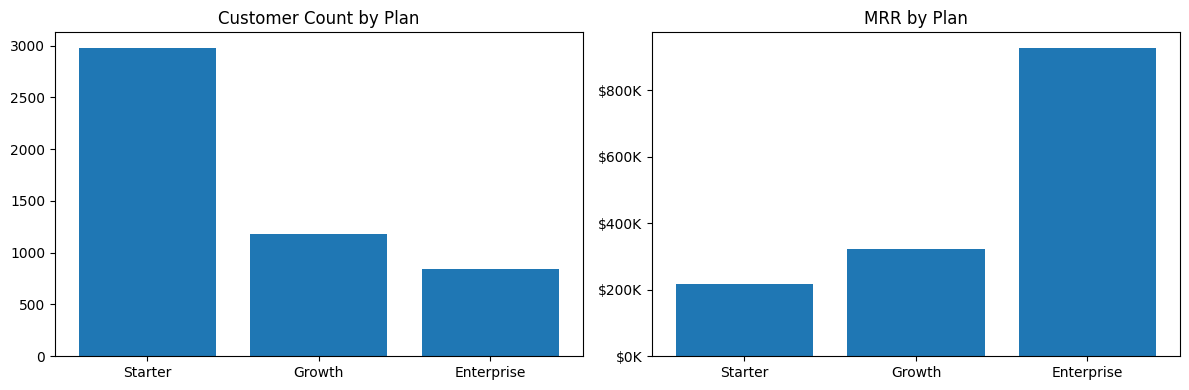

In [5]:

plan_order=['Starter','Growth','Enterprise']
plan_counts=subscriptions['plan_type'].value_counts().reindex(plan_order)
plan_mrr=subscriptions.groupby('plan_type')['mrr'].sum().reindex(plan_order)

fig,(ax1,ax2)=plt.subplots(1,2,figsize=(12,4))

ax1.bar(plan_order, plan_counts)
ax1.set_title('Customer Count by Plan')

ax2.bar(plan_order, plan_mrr)
ax2.set_title('MRR by Plan')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_m))

plt.tight_layout()
save_chart('plan_profile')
plt.show()


## 4. Monthly MRR Trend

Saved: mrr_trend.png


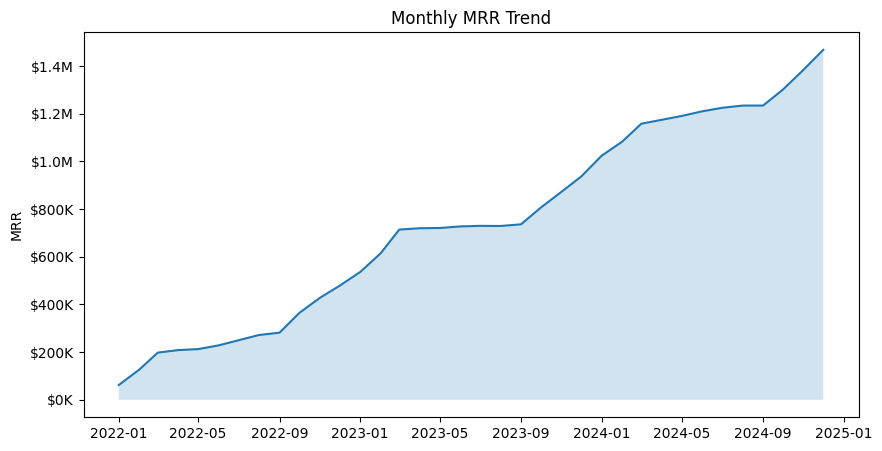

In [6]:

mrr_trend = monthly.groupby('month_dt')['mrr'].sum()

plt.plot(mrr_trend.index, mrr_trend.values)
plt.fill_between(mrr_trend.index, mrr_trend.values, alpha=.2)
plt.title('Monthly MRR Trend')
plt.ylabel('MRR')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(fmt_m))
save_chart('mrr_trend')
plt.show()


## 5. ARR Waterfall

Saved: arr_waterfall.png


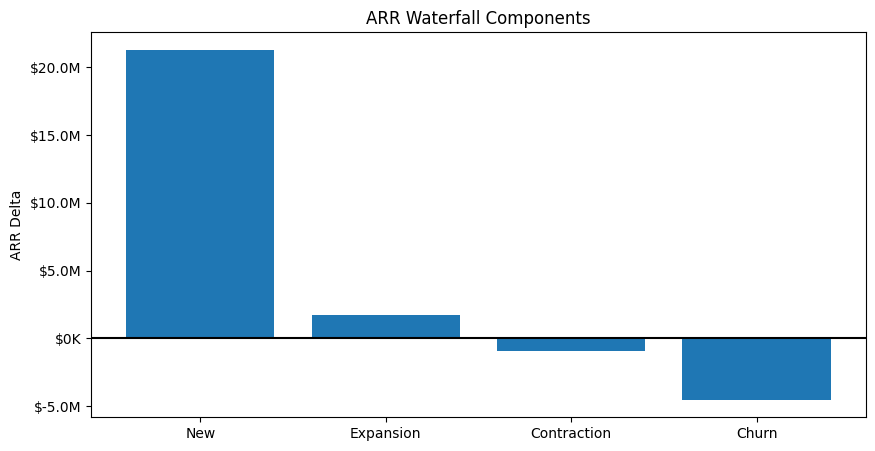

In [7]:

bridge = events.groupby('event_type')['delta_mrr'].sum()

new = bridge.get('new',0)*12
expansion = bridge.get('expansion',0)*12
contraction = bridge.get('contraction',0)*12
churn = bridge.get('churn',0)*12

vals=[new,expansion,contraction,churn]
labs=['New','Expansion','Contraction','Churn']

plt.bar(labs, vals)
plt.axhline(0,color='black')
plt.title('ARR Waterfall Components')
plt.ylabel('ARR Delta')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(fmt_m))
save_chart('arr_waterfall')
plt.show()


## 6. Churn Diagnostics

Saved: monthly_churn.png


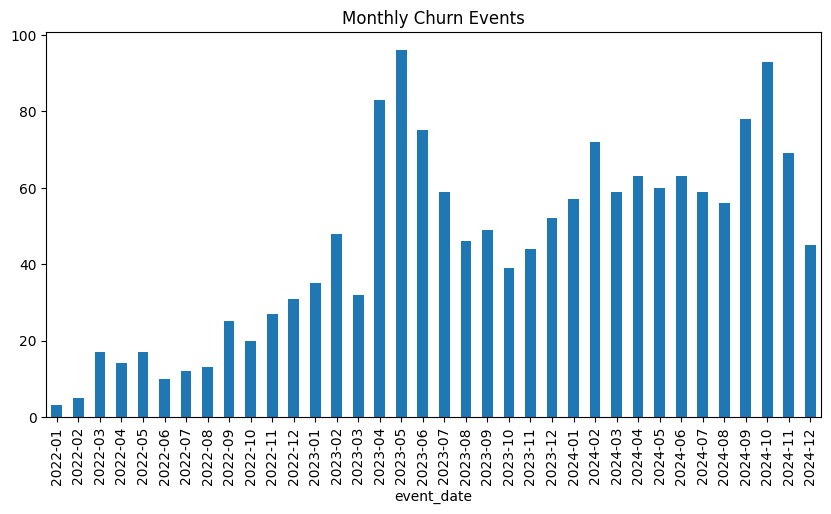

In [8]:

churn_events=events[events.event_type=='churn']
monthly_churn=churn_events.groupby(
    churn_events.event_date.dt.to_period('M')
).size()

monthly_churn.plot(kind='bar')
plt.title('Monthly Churn Events')
save_chart('monthly_churn')
plt.show()


Saved: churn_by_plan.png


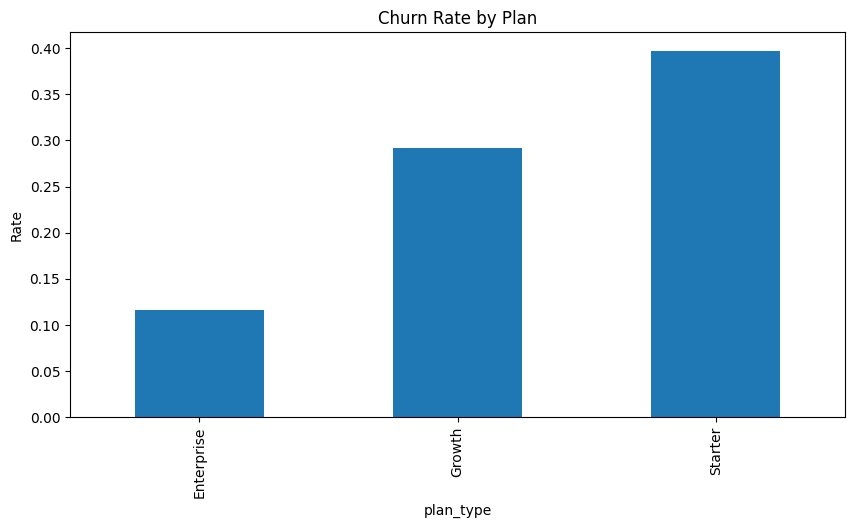

In [9]:

subscriptions.groupby('plan_type')['churned'].mean().plot(kind='bar')
plt.title('Churn Rate by Plan')
plt.ylabel('Rate')
save_chart('churn_by_plan')
plt.show()


## 7. Expansion vs Contraction

Saved: expansion_vs_contraction.png


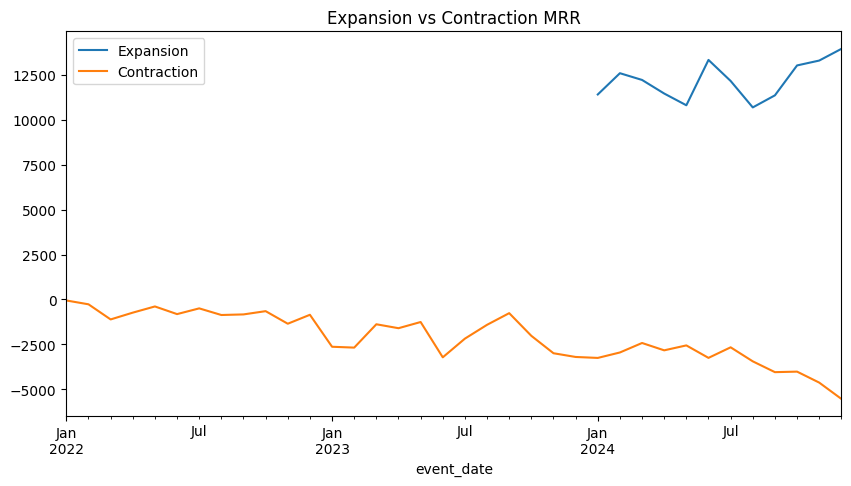

In [10]:

exp = events[events.event_type=='expansion'].groupby(
    events.event_date.dt.to_period('M')
)['delta_mrr'].sum()

con = events[events.event_type=='contraction'].groupby(
    events.event_date.dt.to_period('M')
)['delta_mrr'].sum()

exp.plot(label='Expansion')
con.plot(label='Contraction')
plt.legend()
plt.title('Expansion vs Contraction MRR')
save_chart('expansion_vs_contraction')
plt.show()


## 8. Cohort Retention

Saved: cohort_heatmap.png


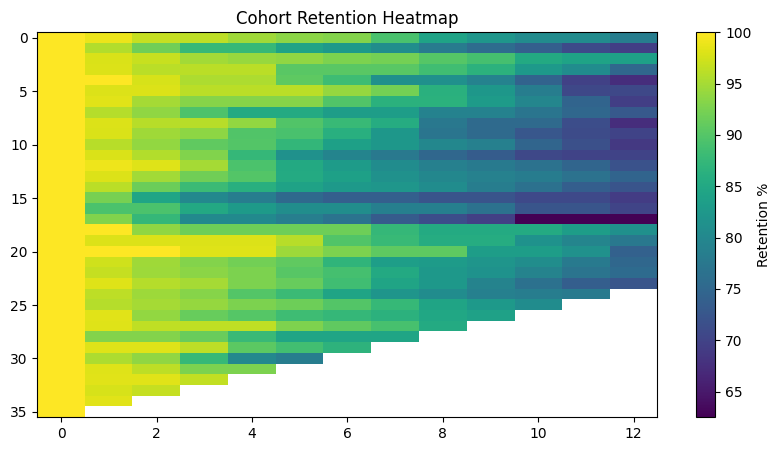

In [11]:

subscriptions['signup_month']=subscriptions['start_date'].dt.to_period('M')

monthly2=monthly.merge(
    subscriptions[['customer_id','signup_month']],
    on='customer_id'
)

monthly2['month_period']=pd.PeriodIndex(monthly2['month'],freq='M')

monthly2['cohort_index']=(
    (monthly2['month_period'].dt.year-
     monthly2['signup_month'].dt.year)*12 +
    (monthly2['month_period'].dt.month-
     monthly2['signup_month'].dt.month)
)

active=monthly2[monthly2['mrr']>0]

cohort=active.pivot_table(
    index='signup_month',
    columns='cohort_index',
    values='customer_id',
    aggfunc='nunique'
)

retention=cohort.divide(cohort[0],axis=0)*100

plt.imshow(retention.iloc[:,:13], aspect='auto')
plt.colorbar(label='Retention %')
plt.title('Cohort Retention Heatmap')
save_chart('cohort_heatmap')
plt.show()


## 9. Acquisition Channel Economics

In [12]:

spend=marketing.groupby('channel')['spend'].sum()
cust=customers['acquisition_channel'].value_counts()

cac=(spend/cust).round(2)
ltv=subscriptions.groupby('acquisition_channel')['lifetime_value'].mean()

econ=pd.DataFrame({
    'CAC':cac,
    'Avg_LTV':ltv
})

econ['LTV_CAC']=(econ['Avg_LTV']/econ['CAC']).round(2)
econ.sort_values('LTV_CAC',ascending=False)


,CAC,Avg_LTV,LTV_CAC
LinkedIn Ads,666.80,35449.820323,53.16
Partner,650.28,34109.786181,52.45
Paid Search,661.46,33890.915331,51.24
Referral,642.12,32618.219274,50.80
Organic,655.86,32831.578162,50.06


## 10. Executive Summary & Key Findings

In [13]:

total_mrr=subscriptions['mrr'].sum()
ent=subscriptions[subscriptions.plan_type=='Enterprise']['mrr'].sum()
ent_share=(ent/total_mrr)*100

print(f'''
KEY FINDINGS
------------
1. Enterprise contributes {ent_share:.1f}% of total MRR.
2. Overall churn is {subscriptions.churned.mean():.1%}.
3. Expansion events: {(events.event_type=='expansion').sum():,}
4. Churn events: {(events.event_type=='churn').sum():,}
5. Best acquisition channel:
{econ['LTV_CAC'].idxmax()} ({econ['LTV_CAC'].max():.2f}x LTV:CAC)
''')



KEY FINDINGS
------------
1. Enterprise contributes 63.2% of total MRR.
2. Overall churn is 32.5%.
3. Expansion events: 2,479
4. Churn events: 1,626
5. Best acquisition channel:
LinkedIn Ads (53.16x LTV:CAC)

